In [17]:
import trimesh
import numpy as np
import torch
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

import sys, os
sys.path.append(os.path.abspath("../src"))

from core import *
import viz as viz

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device ->", device)

cell_cfg = CellConfig(hidden_channels=8, visible_channels=4, alive_threshold=0.05)
perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=True, fire_rate=0.5)
grid_cfg = GridConfig(size=(32, 32, 32))

model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)

device -> cuda


In [ ]:
from scipy.ndimage import zoom

def create_rgba_grid_from_obj(obj_path: str, grid_size=(32, 32, 32), device='cuda') -> torch.Tensor:
    # Load mesh
    mesh = trimesh.load(obj_path, process=True)
    if isinstance(mesh, trimesh.Scene):
        mesh = trimesh.util.concatenate(mesh.geometry.values())
    if not hasattr(mesh.visual, 'face_colors'):
        mesh.visual = mesh.visual.to_color()
    
    # Center and scale mesh to fit grid
    bounds = mesh.bounds
    center = (bounds[0] + bounds[1]) / 2
    scale = (bounds[1] - bounds[0]).max()
    mesh.vertices = (mesh.vertices - center) / scale * 0.8 # 80%
    
    pitch = (mesh.bounds[1] - mesh.bounds[0]).max() / max(grid_size)
    
    vox = mesh.voxelized(pitch=pitch, method='subdivide')
    vox_matrix = vox.matrix.astype(bool)
    
    factors = np.array(grid_size) / np.array(vox_matrix.shape)
    matrix = zoom(vox_matrix.astype(float), factors, order=0) > 0.5
    matrix = matrix.astype(bool)
    
    print(f"Voxel grid shape: {matrix.shape}, occupied voxels: {np.sum(matrix)}")
    
    color_grid = np.zeros((*grid_size, 3), dtype=np.float32)
    face_colors = mesh.visual.face_colors[:, :3] / 255.0
    
    occupied_indices = np.argwhere(matrix)
    if len(occupied_indices) > 0:
        centers = (occupied_indices / np.array(grid_size)) * 1.6 - 0.8  # match scaling above
        closest_pts, distances, triangle_ids = trimesh.proximity.closest_point(mesh, centers)
        for idx, tri_id in enumerate(triangle_ids):
            x, y, z = occupied_indices[idx]
            color_grid[x, y, z] = face_colors[tri_id]
    
    alpha_grid = matrix.astype(np.float32)
    rgba_np = np.concatenate([color_grid, alpha_grid[..., np.newaxis]], axis=-1)
    
    # To torch tensor [1, 4, X, Y, Z]
    target = torch.from_numpy(rgba_np.transpose(3, 0, 1, 2)).unsqueeze(0).float().to(device)
    
    return target

target = create_rgba_grid_from_obj("../assets/donut/model.obj")
print("Output tensor shape:", target.shape)


Voxel grid shape: (32, 32, 32), occupied voxels: 6677
Output tensor shape: torch.Size([1, 4, 32, 32, 32])


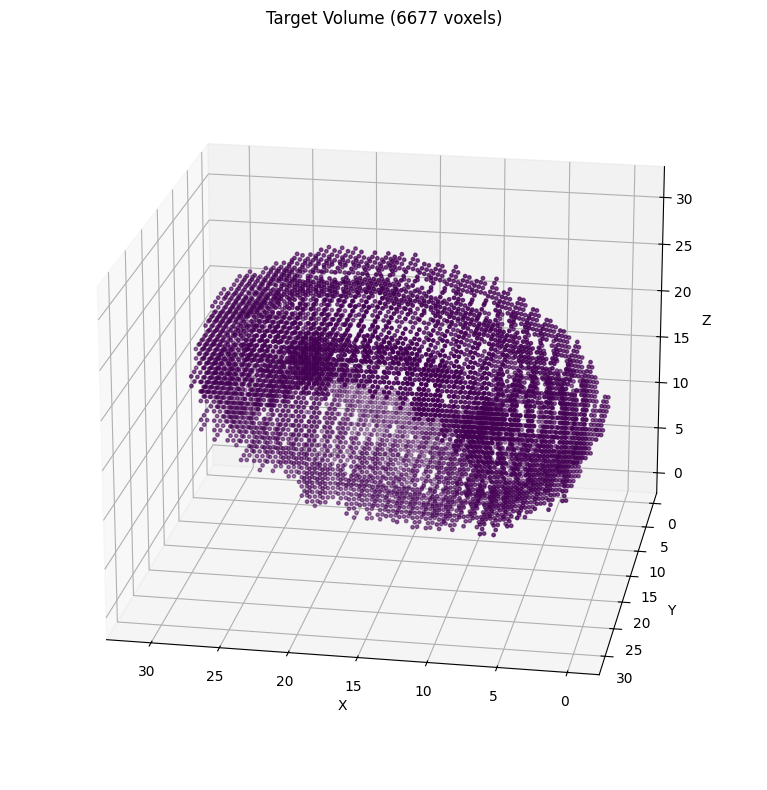

Widget(value='<iframe src="http://localhost:52763/index.html?ui=P_0x1e420026a50_2&reconnect=auto" class="pyvis…

In [20]:
viz.show_volume_target_mpl(target,view_angle=(20, 100))
viz.show_volume_target_color(target, notebook=True)

In [21]:
print("stability run:")
state = model.seed_center(batch_size=1, device=device)
state += 1e-3 * torch.randn_like(state)
with torch.no_grad():
    for i in range(8):
        state = model(state, steps=1)
        print(f"step {i:02d} mean={state.mean().item():+.6f} std={state.std().item():.6f}")

stability run:
step 00 mean=+0.000007 std=0.002306
step 01 mean=+0.000009 std=0.002820
step 02 mean=+0.000009 std=0.002986
step 03 mean=+0.000010 std=0.003194
step 04 mean=+0.000010 std=0.003201
step 05 mean=+0.000010 std=0.003213
step 06 mean=+0.000010 std=0.003258
step 07 mean=+0.000009 std=0.003269


Iter 00001, Loss=1.069301, Mean value=-0.0000


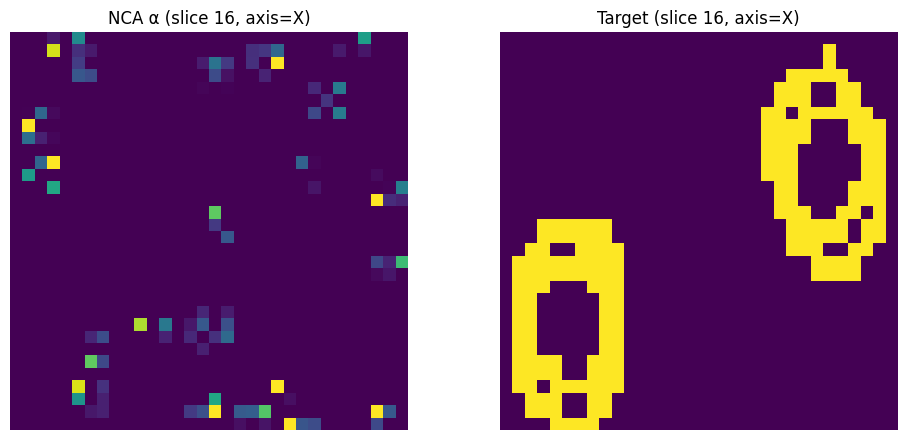

Iter 00200, Loss=1.004920, Mean value=0.0231


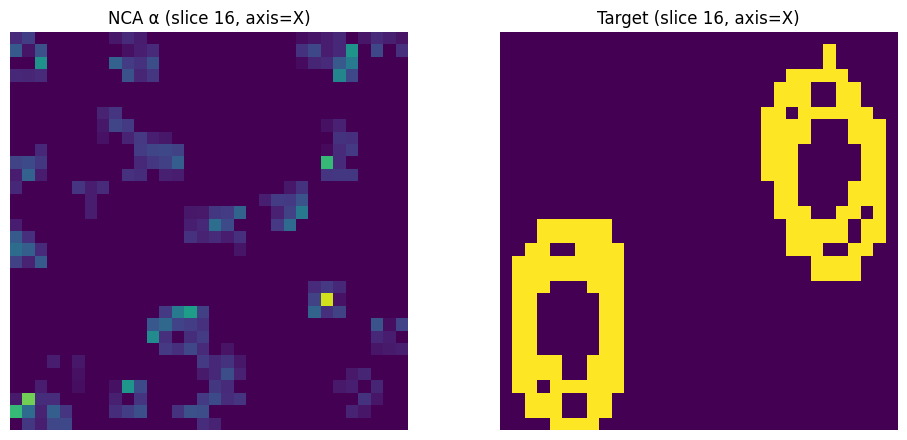

Iter 00400, Loss=1.004256, Mean value=0.0242


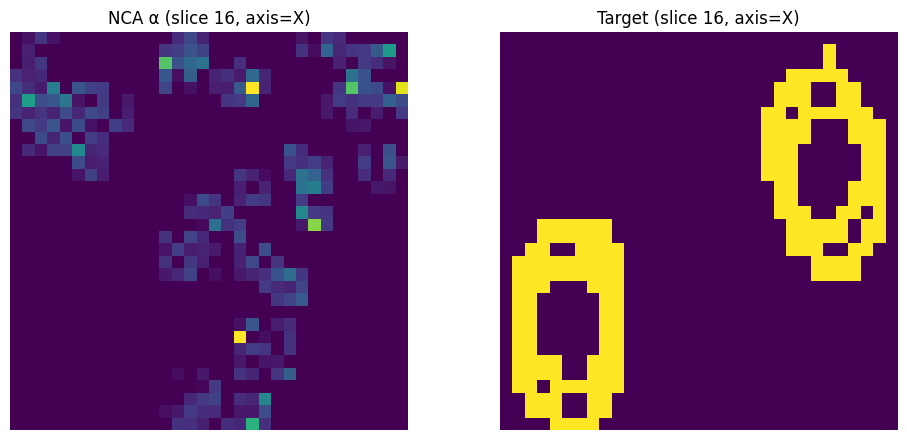

Iter 00600, Loss=1.005951, Mean value=0.0365


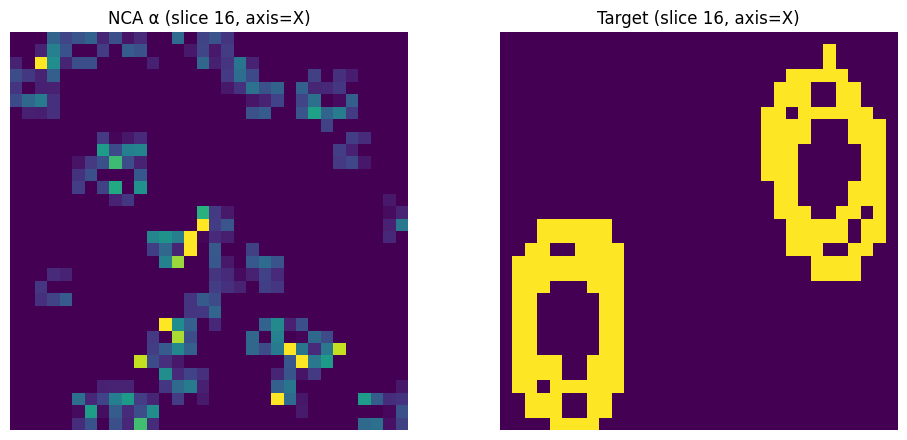

Iter 00800, Loss=1.003854, Mean value=0.0273


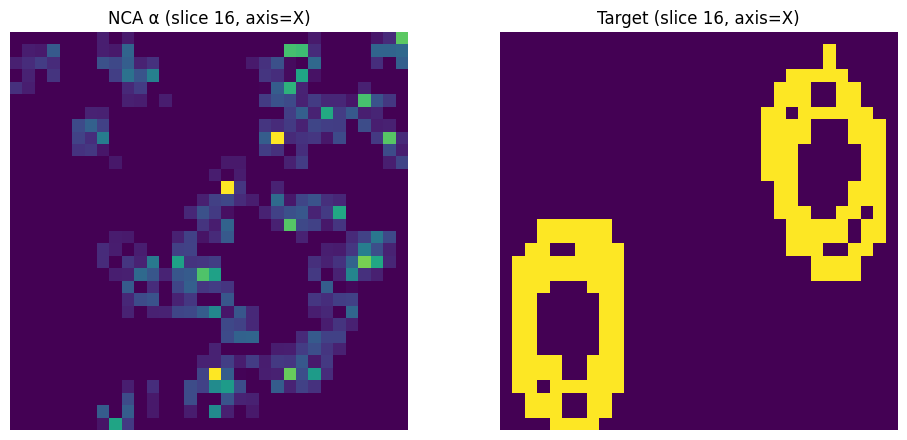

Iter 01000, Loss=1.001353, Mean value=0.0437


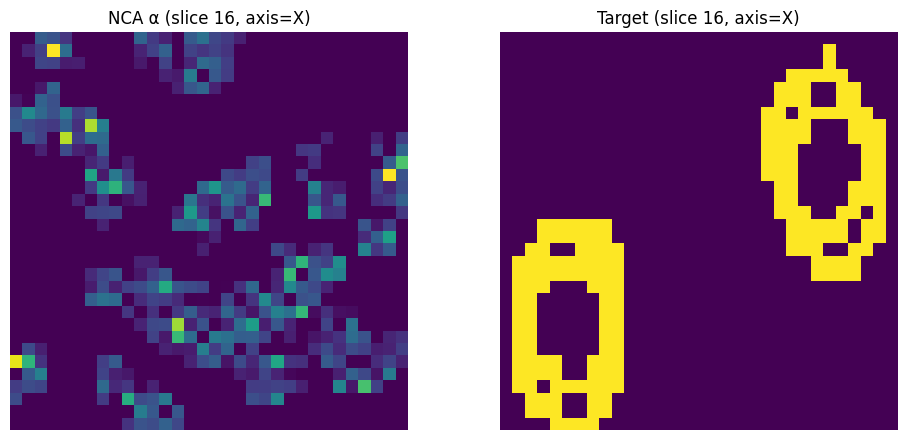

Iter 01200, Loss=0.999877, Mean value=0.0434


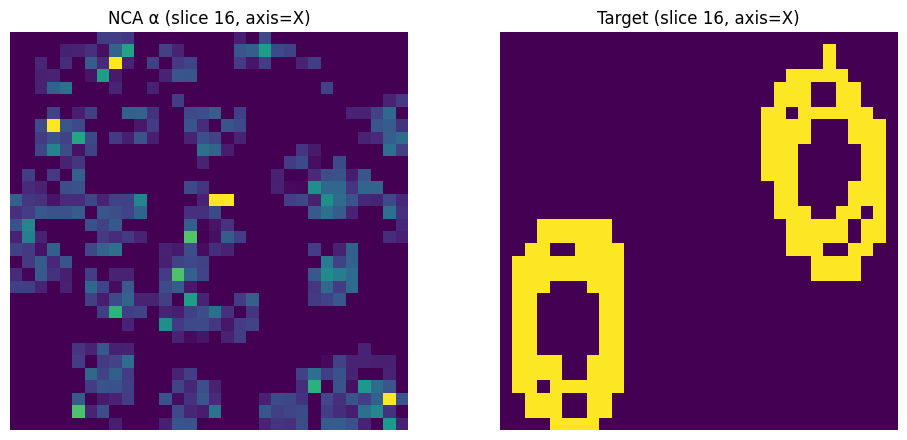

Iter 01400, Loss=0.996474, Mean value=0.0375


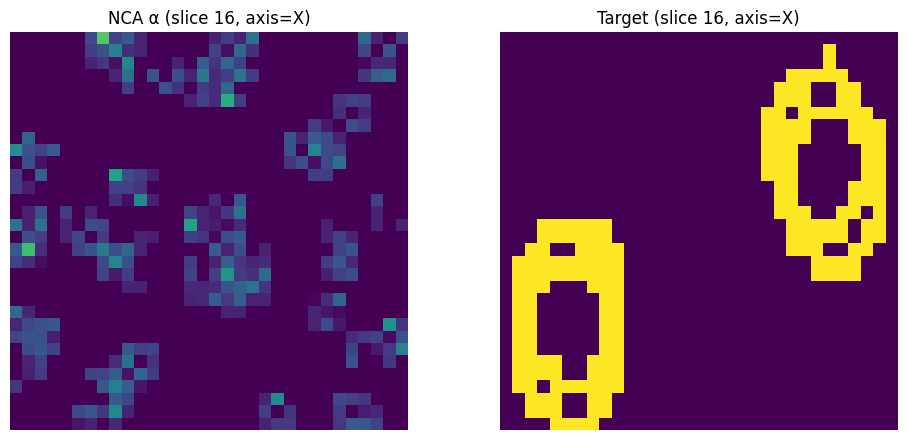

Iter 01600, Loss=1.000135, Mean value=0.0402


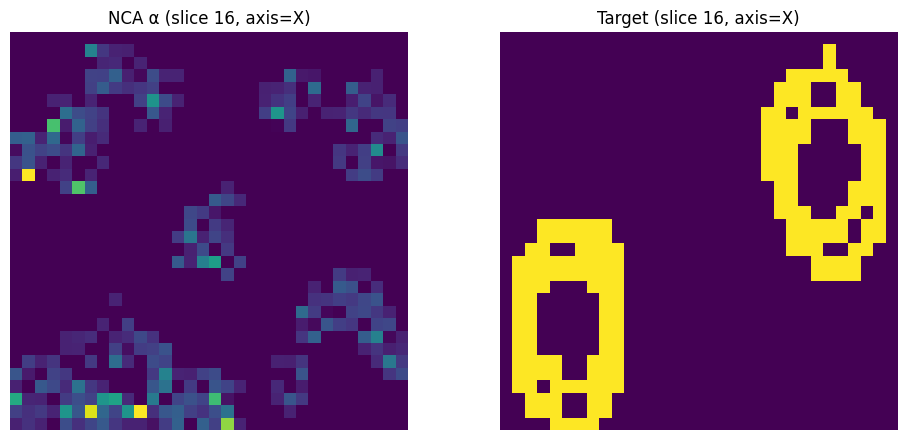

Iter 01800, Loss=0.998515, Mean value=0.0442


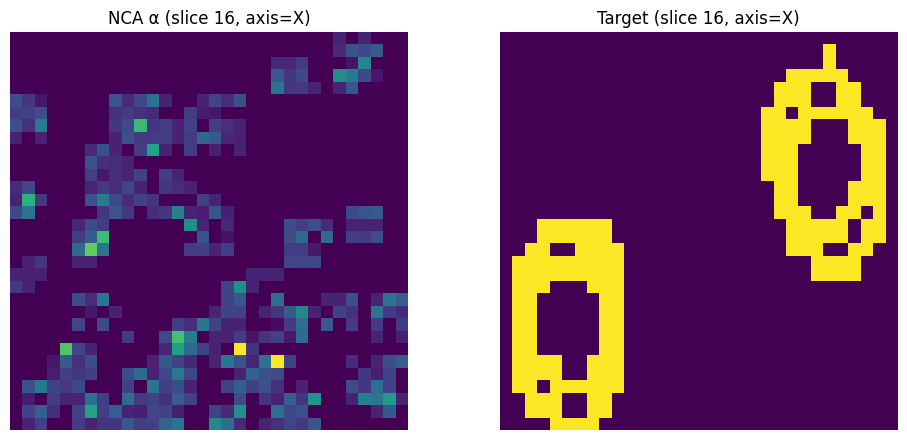

Iter 02000, Loss=1.001130, Mean value=0.0348


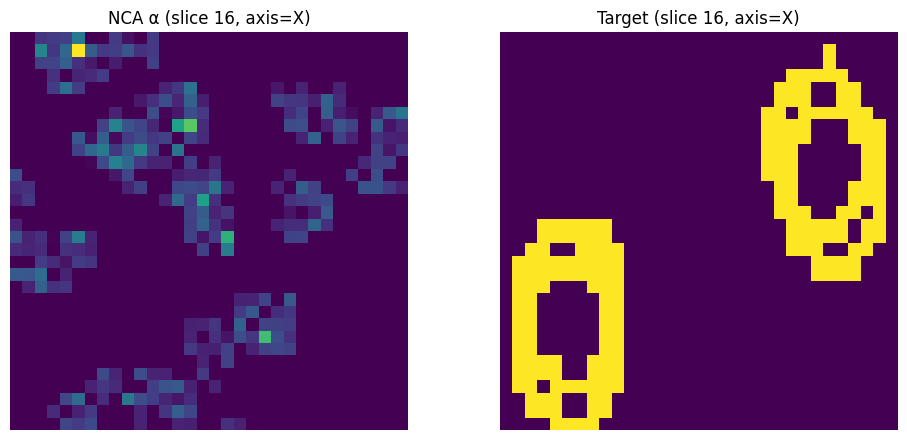

training took 80.93586921691895 s


In [22]:
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
losses = []
iters = 2000
n_steps = 8
log_interval = 200

start = time.time()
for it in range(1, iters + 1):
    state = model.seed_center(batch_size=1, device=device)
    state += 0.02 * torch.randn_like(state)

    optim.zero_grad()
    loss = 0.

    for step in range(n_steps):
        state = model(state, steps=1)
        rgb_alpha_out = state[:, :4:, ...]  # last 4 channels (RGB + alpha)
        loss += F.mse_loss(rgb_alpha_out, target)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optim.step()
    losses.append(loss.item())

    if it % log_interval == 0 or it == 1:
        mean_val = rgb_alpha_out.mean().item()
        print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean value={mean_val:.4f}")
        viz.show_slice_comparison(rgb_alpha_out, target, idx=16)

print("training took", time.time() - start, "s")

final alive voxels: 1


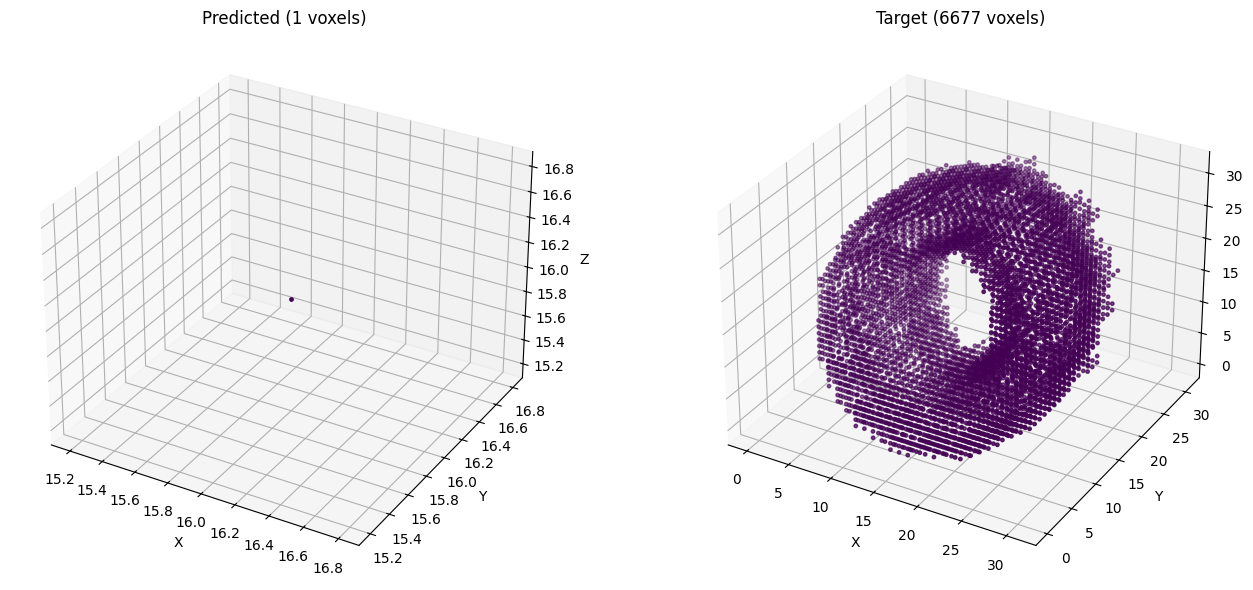

(1, 6677)

In [23]:
with torch.no_grad():
    state = model.seed_center(batch_size=1, device=device)
    state += 1e-3 * torch.randn_like(state)
    state = model(state, steps=8)
    alpha = state[:, -1:, ...].cpu().numpy().squeeze()

thresh = 0.2
xs, ys, zs = np.nonzero(alpha > thresh)
print("final alive voxels:", len(xs))
viz.show_volume_comparison_mpl(state, target)

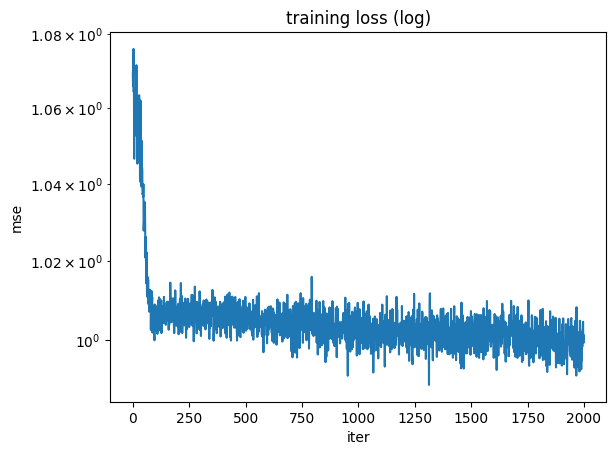

In [24]:
plt.figure()
plt.plot(losses)
plt.yscale("log")
plt.title("training loss (log)")
plt.xlabel("iter")
plt.ylabel("mse")
plt.show()